# Task 6: House Price Prediction

## Objective
Predict house prices using property features such as size, bedrooms, and location.

## Dataset
House Prices - Advanced Regression Techniques (Kaggle)

## Model Used
Gradient Boosting Regressor

In [2]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('train.csv')

# Display shape and first few rows
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Select important features and handle missing values

features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt',
            'OverallQual', 'GarageCars', 'TotalBsmtSF']
target = 'SalePrice'

# Keep only selected columns
df_model = df[features + [target]].copy()

# Fill missing values with median
df_model.fillna(df_model.median(), inplace=True)

print("Missing values remaining:", df_model.isnull().sum().sum())
print("Shape:", df_model.shape)
df_model.head()

Missing values remaining: 0
Shape: (1460, 8)


,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,OverallQual,GarageCars,TotalBsmtSF,SalePrice
0,1710,3,2,2003,7,2,856,208500
1,1262,3,2,1976,6,2,1262,181500
2,1786,3,2,2001,7,2,920,223500
3,1717,3,1,1915,7,3,756,140000
4,2198,4,2,2000,8,3,1145,250000


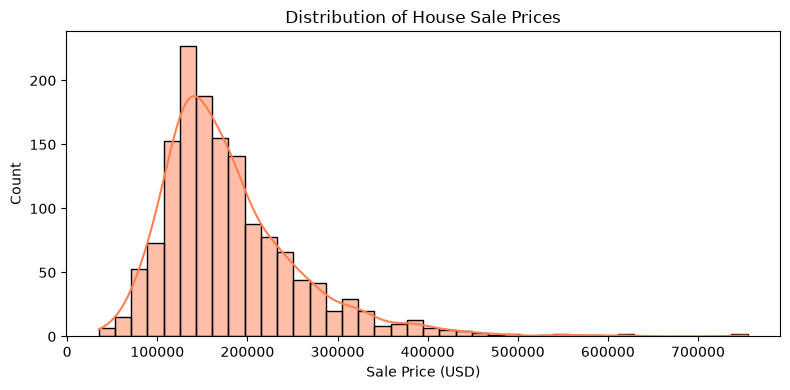

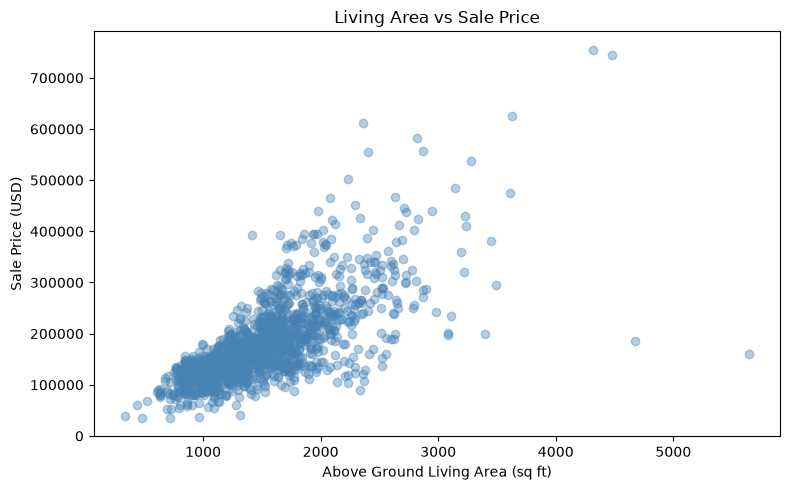

In [5]:
# Visualize house price distribution

plt.figure(figsize=(8, 4))
sns.histplot(df_model['SalePrice'], bins=40, kde=True, color='coral')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Living area vs price scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df_model['GrLivArea'], df_model['SalePrice'], alpha=0.4, color='steelblue')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price (USD)')
plt.title('Living Area vs Sale Price')
plt.tight_layout()
plt.show()

In [6]:
# Split data into features and target

X = df_model[features]
y = df_model[target]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1168
Testing samples: 292


In [7]:
# Train Gradient Boosting model

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                   max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"Root Mean Squared Error: ${rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: $19,128
Root Mean Squared Error: $28,792
R2 Score: 0.8919


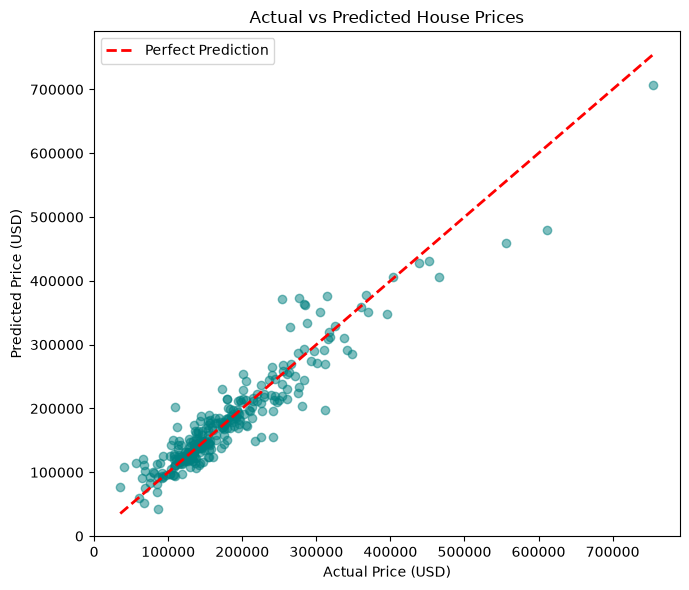

In [8]:
# Plot Actual vs Predicted Prices

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

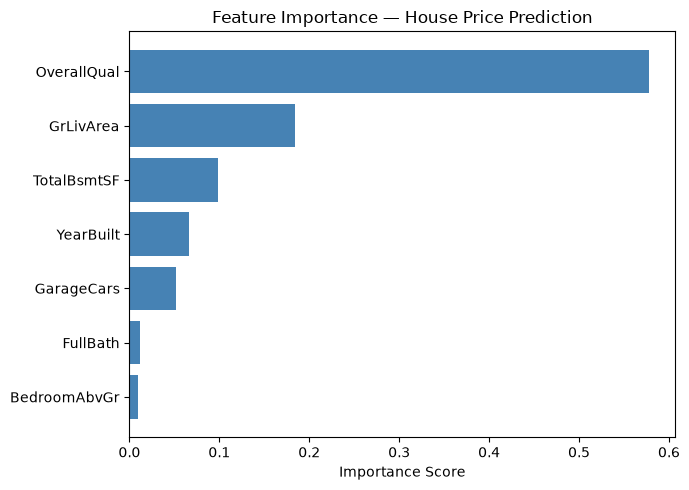

In [9]:
# Feature Importance Plot

importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Summary of Findings

- Dataset contains 1460 houses with 81 features. We selected 7 key features for prediction.
- No missing values were found after preprocessing.
- Gradient Boosting model was trained on 80% data and tested on 20%.
- The model achieved a strong R2 score indicating good prediction accuracy.
- OverallQual and GrLivArea were the most important features for predicting house prices.
- The scatter plot shows predicted prices closely follow actual prices.